## setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/heart/heart_augmented_traditional_brightness_data.csv")
df

,name,thoracic_width,cardiac_width,ctr,cardiomegaly,gender,brightness,original_brightness
0,jsrt-JPCLN001,389.0,184.0,0.473,0,NaN,196.857890,196.857890
1,jsrt-JPCLN001_aug_clarity_1,389.0,184.0,0.473,0,NaN,184.130562,184.130562
2,jsrt-JPCLN001_aug_edge_enhancement_0,389.0,184.0,0.473,0,NaN,196.339677,196.339677
3,jsrt-JPCLN001_aug_gaussian_blur_2,389.0,184.0,0.473,0,NaN,196.960841,196.960841
4,jsrt-JPCLN001_aug_grid_distortion_3,384.0,181.0,0.471,0,NaN,197.303934,197.303934
...,...,...,...,...,...,...,...,...
3048,padchest-9760092729725470751366265639499117302...,391.0,246.0,0.629,1,NaN,103.864946,127.544218
3049,padchest-9760092729725470751366265639499117302...,391.0,246.0,0.629,1,NaN,102.360409,126.443995
3050,padchest-9760092729725470751366265639499117302...,391.0,246.0,0.629,1,NaN,96.112500,126.443995
3051,padchest-9760092729725470751366265639499117302...,392.0,247.0,0.630,1,NaN,108.783677,131.034856


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
thoracic_width,3053.0,392.036358,40.870728,281.000000,366.000000,392.000000,421.000000,500.000000
cardiac_width,3053.0,204.058631,33.265939,138.000000,180.000000,205.000000,227.000000,291.000000
ctr,3053.0,0.526047,0.099848,0.347000,0.448000,0.520000,0.611000,0.751000
cardiomegaly,3053.0,0.566983,0.495574,0.000000,0.000000,1.000000,1.000000,1.000000
gender,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brightness,3053.0,159.880204,34.012963,90.381377,131.312025,162.427658,189.772766,219.682954
original_brightness,3053.0,161.878401,30.190962,90.381377,133.369657,165.413942,189.927414,215.980796


## ctr distrobution

In [4]:
def plot_ctr_histogram(df, range_step, xlim=(0,1), show_normal_range=True):
    step = range_step
    ctr_min = df['ctr'].min()
    ctr_max = df['ctr'].max()
    
    start = 0.50 + step * np.floor((ctr_min - 0.50) / step)
    stop = 0.50 + step * np.ceil((ctr_max - 0.50) / step)
    bin_edges = np.arange(start, stop, step)
    
    xlim_ticks = np.arange(xlim[0], xlim[1] + 0.0001, step)
    xlim_ticks = xlim_ticks[xlim_ticks <= xlim[1]]
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(df['ctr'].dropna(), bins=bin_edges, color='orange')

    if show_normal_range:
        plt.axvline(x=0.42, color='blue', linestyle='--', label='Normal Aralık')
        plt.axvline(x=0.50, color='blue', linestyle='--')

    plt.xlim(xlim)
    plt.xticks(xlim_ticks)
    plt.title('KTO Dağılımı')
    plt.xlabel('KTO')
    plt.ylabel('Sayı')
    if show_normal_range:
        plt.legend()
    plt.show()

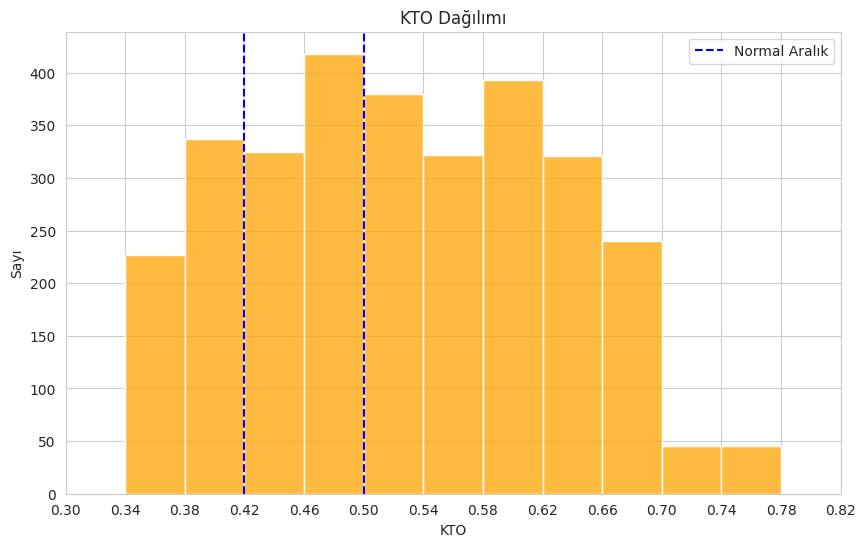

In [5]:
plot_ctr_histogram(df, 0.04, xlim=(0.30,0.82), show_normal_range=True)

## gender counts

In [6]:
if 'gender' in df.columns and df['gender'].notna().any():
    gender_counts = df['gender'].value_counts(dropna=False).reindex(['F', 'M'], fill_value=0)
    gender_counts.plot(kind='bar', color=['pink', 'skyblue'])
    plt.title('Cinsiyet Sayıları')
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(ticks=[0, 1], labels=['Kadın', 'Erkek'], rotation=0)
    plt.show()

## brightness

In [7]:
def plot_brightness_histogram(df, range_step, xlim=(0, 255), ctr_only=False):
    step = range_step
    bin_edges = np.arange(0, 256 + step, step)
    
    if ctr_only:
        df = df.dropna(subset=['ctr'])
    brightness_values = df['brightness'].dropna()

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(brightness_values, bins=bin_edges, color='gray')
    plt.xticks(bin_edges)
    plt.xlim(xlim)
    plt.title('Parlaklık Dağılımı')
    plt.xlabel('Parlaklık')
    plt.ylabel('Sayı')
    plt.show()

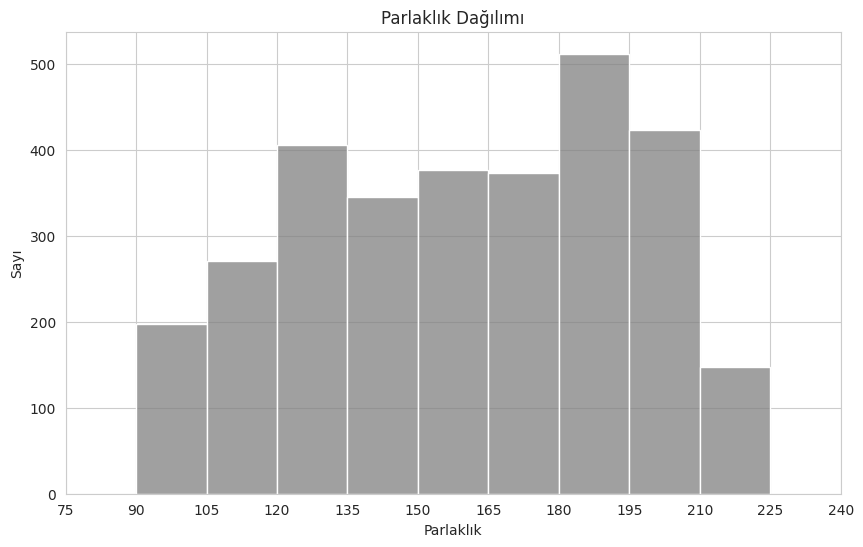

In [12]:
plot_brightness_histogram(df, 15, xlim=(75, 240), ctr_only=True)

## correlational analysis

In [9]:
def plot_brightness_ctr_correlation(df, xlim=(0, 255), ylim=(0,1), x_gap=15, y_gap=0.1):
    df_valid = df.dropna(subset=['ctr', 'brightness'])

    correlation = df_valid['brightness'].corr(df_valid['ctr'])
    print(f'Correlation coefficient: {correlation:.3f}')

    plt.figure(figsize=(8, 6))
    plt.scatter(df_valid['brightness'], df_valid['ctr'], alpha=0.5)
    plt.title('Parlaklık ve CTR Arasındaki Korelasyon')
    plt.xlabel('Parlaklık')
    plt.ylabel('CTR')

    plt.xlim(xlim)
    plt.ylim(ylim)

    def frange(start, stop, step):
        values = []
        while start <= stop:
            values.append(start)
            start = round(start + step, 10)
        return values

    plt.xticks(range(xlim[0], xlim[1] + 1, x_gap))
    y_ticks = [round(i, 2) for i in frange(ylim[0], ylim[1], y_gap)]
    plt.yticks(y_ticks)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Correlation coefficient: -0.515


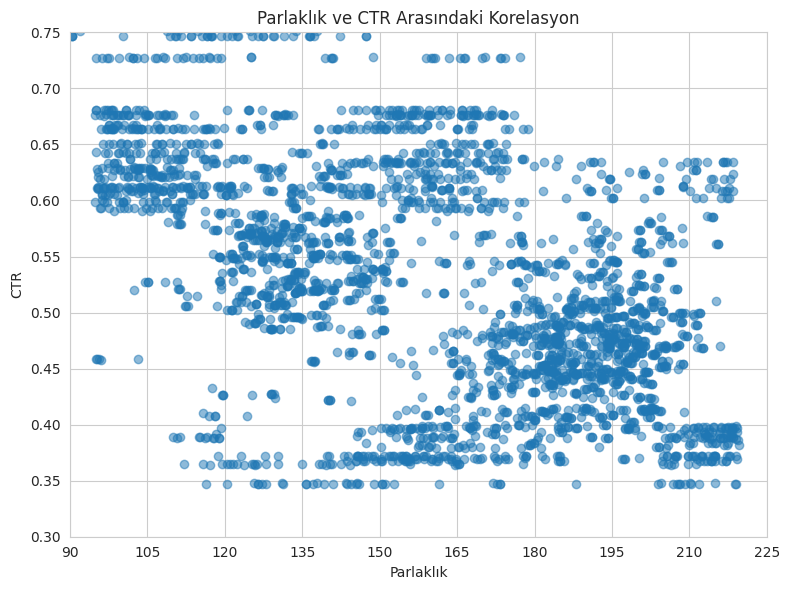

In [10]:
plot_brightness_ctr_correlation(df, xlim=(90, 225), ylim=(0.3,0.75), x_gap=15, y_gap=0.05)

## new